In [ ]:
%reload_ext autoreload
%autoreload 2

from __future__ import annotations
from dataclasses import dataclass, field
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for candidate in (Path.cwd(), Path.cwd().parent):
    pymrm_src = candidate / "pymrm" / "src"
    if pymrm_src.exists() and str(pymrm_src) not in sys.path:
        sys.path.insert(0, str(pymrm_src))

from pymrm import (
    NumJac,
    construct_coefficient_matrix,
    construct_convflux_upwind,
    construct_div,
    construct_grad,
    newton,
    non_uniform_grid,
)

from config import ModelConfig
from buildoperators import TransportOperators
from membrane import MembraneReactorModel
from reaction import ReactionRates

In [ ]:
cfg = ModelConfig()
build = TransportOperators(cfg)
model = MembraneReactorModel(cfg)
reaction = ReactionRates(cfg)

result = model.solve()

c_g, c_b, c_p, c_m = model.fields()
RT = cfg.R * cfg.T
P_at_outlet = c_p[-1, -1, :] * RT
r1, r2 = reaction.reaction_rates(c_b[:, None, :], cfg)

print(pd.Series(
    {
        "axial cells":               cfg.n_z,
        "particle radial cells":     cfg.n_r_ret,
        "reactor length [m]":        cfg.length,
        "v_ret [m/s]":               cfg.v_ret,
        "solid holdup [-]":          cfg.eps_s,
        "external area [1/m]":       cfg.external_area,
    },
    name="settings",
))
 
print(pd.Series(
    {
        "k_eff_MeOH":                cfg.k_eff_r1(),
        "k_eff_DMC (R2)":            cfg.k_eff_r2(cfg.p),
        "p_CO2 [Pa]":                P_at_outlet[0],
        "p_H2 [Pa]":                 P_at_outlet[1],
        "p_CH3OH [Pa]":              P_at_outlet[2],
        "p_H2O [Pa]":                P_at_outlet[3],
        "p_DMC [Pa]":                P_at_outlet[4],
        "r1 [mol/m³/s]":             r1[-1, 0],
        "r2 [mol/m³/s]":             r2[-1, 0],
    },
    name="reaction values",
))

print(pd.Series(
    {
        "success":                           result.success,
        "Newton iterations":                 result.nit,
        "final residual norm (inf)":         np.linalg.norm(result.fun, ord=np.inf),
        "outlet CO2 conversion [-]":         1.0 - c_g[-1, 0] / c_g[0, 0],
        "outlet H2 conversion [-]":          1.0 - c_g[-1, 1] / c_g[0, 1],
        "outlet DMC concentration [mol/m³]": c_g[-1, 4],
        "outlet CO2 concentration [mol/m³]": c_g[-1, 0],
        "outlet H2 concentration [mol/m³]":  c_g[-1, 1],
        "outlet CH3OH concentration [mol/m³]": c_g[-1, 2],
        "outlet H2O permeate concentration [mol/m³]": c_m[-1, 3],
    },
    name="result",
))

ValueError: array must not contain infs or NaNs

NameError: name 'c_g' is not defined

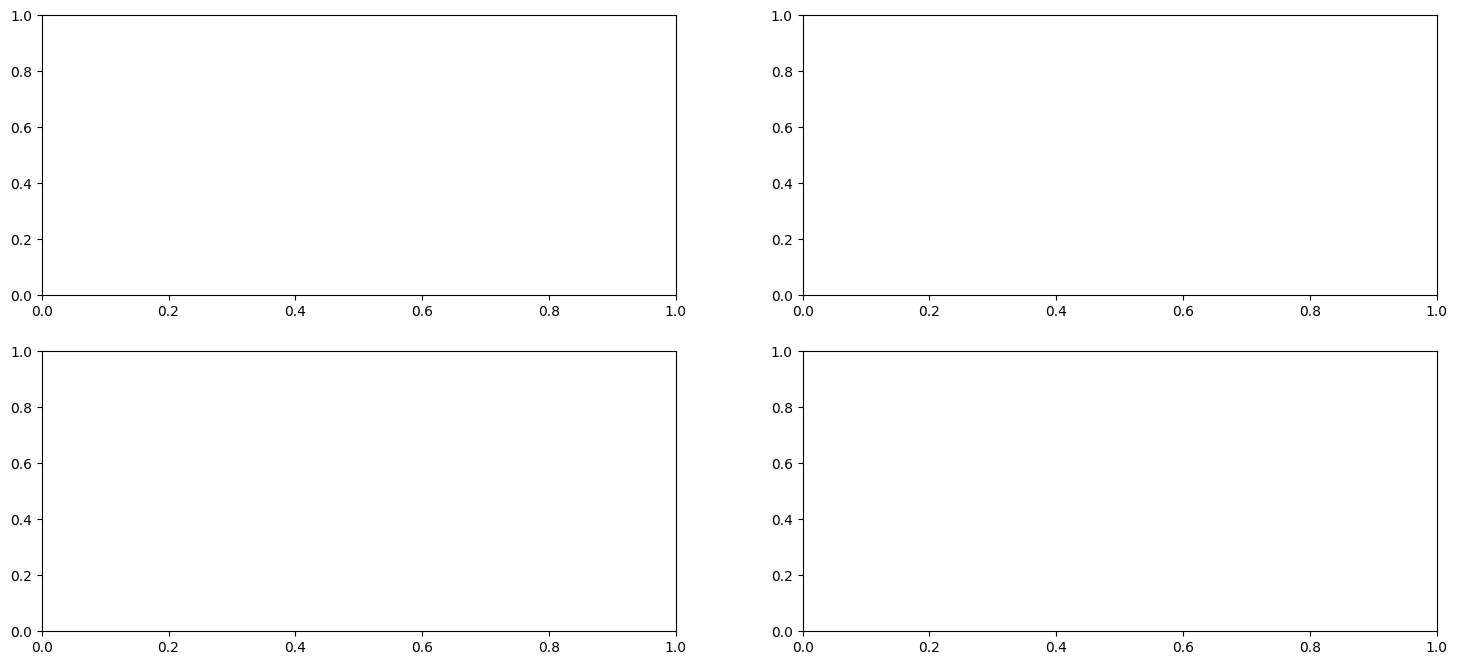

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 8), sharex=False)
axes = axes.flatten()
 
# axes[0]: Bulk Gas Concentration
for i, label in enumerate(model.species_labels):
    axes[0].plot(model.z_c, c_g[:, i], label=label, linewidth=2)
axes[0].axhline(0.0, color="k", linewidth=0.8)
axes[0].set_xlabel("z [m]")
axes[0].set_ylabel("Concentration [mol m$^{-3}$]")
axes[0].set_title("Bulk gas concentration")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), ncol=1, fontsize=8, frameon=True)
axes[0].grid(True, linestyle=":", alpha=0.6)
 
# axes[1]: H2O Permeate Concentration
for i, label in enumerate(model.species_labels):
    axes[1].plot(model.z_c, c_m[:, i], label=label, linewidth=2)
axes[1].axhline(0.0, color="k", linewidth=0.8)
axes[1].set_xlabel("z [m]")
axes[1].set_ylabel(r"Concentration [mol m$^{-3}$]")
axes[1].set_title("H2O Permeate concentration")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), ncol=1, fontsize=8, frameon=True)
axes[1].grid(True, linestyle=":", alpha=0.6)
 
# axes[2]: Reaction Rates
axes[2].plot(model.z_c, r1, label=r"$r1$", linewidth=2)
axes[2].plot(model.z_c, r2, label=r"$r2$", linewidth=2)
axes[2].axhline(0.0, color="k", lw=0.8)
axes[2].set_xlabel("z [m]")
axes[2].set_ylabel("Rate [mol m$^{-3}$ s$^{-1}$]")
axes[2].set_title("Reaction rates at pellet boundary")
axes[2].legend(loc="best", fontsize=8)
axes[2].grid(True, linestyle=":", alpha=0.6)
 
# axes[3]: Effectiveness Profile
eta_r1, eta_r2, _, _ = model.effectiveness_profile()
axes[3].plot(model.z_c, eta_r1, label=r"$\eta$ R1", linewidth=2)
axes[3].plot(model.z_c, eta_r2, label=r"$\eta$ R2", linewidth=2)
axes[3].axhline(0.0, color="k", linewidth=0.8, linestyle="--")
axes[3].set_xlabel("z [m]")
axes[3].set_ylabel("Effectiveness factor")
axes[3].set_title(r"Effectiveness ($\eta$)")
axes[3].grid(True, linestyle=":", alpha=0.6)
axes[3].legend(loc="best", fontsize=8)
 
plt.tight_layout()
plt.show()